### IMPORTS

In [1]:
import os
import numpy as numpy
import seaborn as seaborn
import matplotlib.pyplot as plot
import tensorflow as tensorflow
import json
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### REPRODUCIBILITY

In [2]:
numpy.random.seed(42)
tensorflow.random.set_seed(42)

### SET PARAMETERS

In [3]:
image_height = 224
image_width  = 224
batch_size   = 32

train_directory = "../data/brain_tumor/training"
test_directory  = "../data/brain_tumor/testing"

### DATA AUGMENTATION

In [4]:
train_augmenter = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,
    brightness_range=[0.8, 1.2])

validation_augmenter = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2)

### DATA LOADERS

In [5]:
train_loader = train_augmenter.flow_from_directory(
    train_directory,
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True)

validation_loader = validation_augmenter.flow_from_directory(
    train_directory,
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False)

class_names = list(train_loader.class_indices.keys())
print("Classes:", class_names)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


### CLASS WEIGHTS

In [6]:
train_labels = train_loader.classes
class_weight_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=numpy.unique(train_labels),
    y=train_labels)
class_weights = dict(enumerate(class_weight_values))
print("Class weights:", class_weights)

Class weights: {0: 1.0811258278145695, 1: 1.0659981343283582, 2: 0.8955721003134797, 3: 0.9800600343053173}


### BUILD MODEL

In [7]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

inputs = tensorflow.keras.Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = tensorflow.keras.Model(inputs, outputs)

model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"])

### CALLBACKS

In [8]:
callbacks = [ 
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True), 
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1) ]

### INITIAL TRAINING

In [9]:
history_initial = model.fit(
    train_loader,
    epochs=10,
    validation_data=validation_loader,
    callbacks=callbacks,
    class_weight=class_weights)

/Users/radhamurugan/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.5951 - loss: 1.1449 - val_accuracy: 0.7309 - val_loss: 0.7382 - learning_rate: 1.0000e-04
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.8422 - loss: 0.4735 - val_accuracy: 0.7844 - val_loss: 0.6220 - learning_rate: 1.0000e-04
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.8521 - loss: 0.4274 - val_accuracy: 0.7923 - val_loss: 0.5920 - learning_rate: 1.0000e-04
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.8694 - loss: 0.3649 - val_accuracy: 0.8133 - val_loss: 0.5176 - learning_rate: 1.0000e-04
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.8789 - loss: 0.3413 - val_accuracy: 0.8387 - val_loss: 0.5348 - learning_rate: 1.0000e-04
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.8856 - loss: 0.3084 - val_accuracy: 0.8484 - val_loss: 0.4262 - learning_rate: 1.0000e-04
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - acc

### FINE TUNE TRAINING

In [10]:
base_model.trainable = True

for layer_index, layer_item in enumerate(base_model.layers):
    if layer_index < len(base_model.layers) - 120:
        layer_item.trainable = False

for layer_item in base_model.layers:
    if isinstance(layer_item, layers.BatchNormalization):
        layer_item.trainable = False

model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"])

history_finetune = model.fit(
    train_loader,
    epochs=20,
    validation_data=validation_loader,
    callbacks=callbacks,
    class_weight=class_weights)

Epoch 1/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 477s 3s/step - accuracy: 0.9179 - loss: 0.2336 - val_accuracy: 0.8457 - val_loss: 0.4506 - learning_rate: 1.0000e-05
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 473s 3s/step - accuracy: 0.9424 - loss: 0.1658 - val_accuracy: 0.8817 - val_loss: 0.3481 - learning_rate: 1.0000e-05
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 473s 3s/step - accuracy: 0.9534 - loss: 0.1255 - val_accuracy: 0.8861 - val_loss: 0.3480 - learning_rate: 1.0000e-05
Epoch 4/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 468s 3s/step - accuracy: 0.9591 - loss: 0.1139 - val_accuracy: 0.9422 - val_loss: 0.1976 - learning_rate: 1.0000e-05
Epoch 5/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 472s 3s/step - accuracy: 0.9723 - loss: 0.0894 - val_accuracy: 0.9045 - val_loss: 0.3092 - learning_rate: 1.0000e-05
Epoch 6/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 464s 3s/step - accuracy: 0.9773 - loss: 0.0721 - val_accuracy: 0.9308 - val_loss: 0.2083 - learning_rate: 1.0000e-05
Epoch 7/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accur

### SAVE OUTPUTS

In [11]:
save_directory = "../saved"
os.makedirs(save_directory, exist_ok=True)

model.save(os.path.join(save_directory, "resnet_model.h5"))

with open(os.path.join(save_directory, "class_indices.json"), "w") as f:
    json.dump(train_loader.class_indices, f)

with open(os.path.join(save_directory, "class_names.json"), "w") as f:
    json.dump(class_names, f)

### ACCURACY & LOSS PLOT

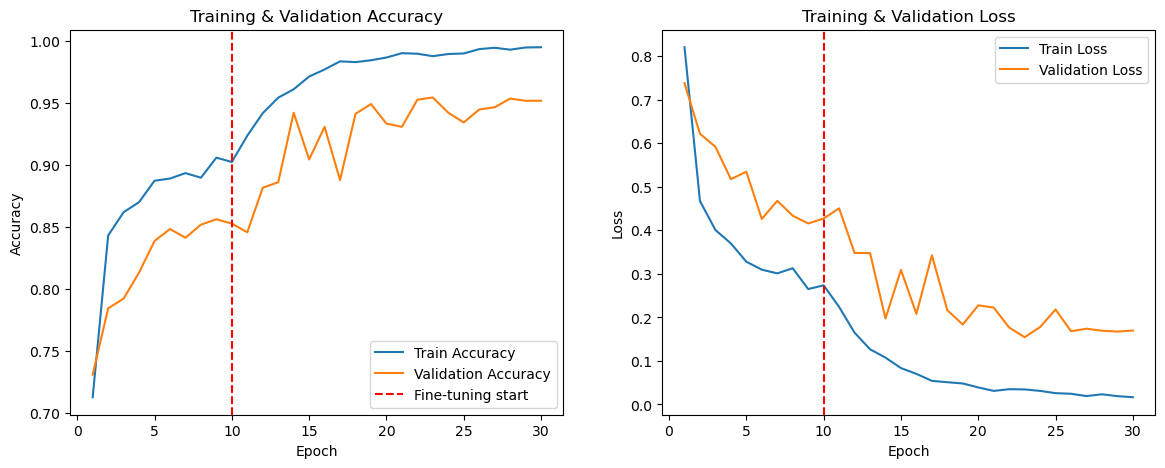

In [12]:
acc      = history_initial.history['accuracy'] + history_finetune.history['accuracy']
val_acc  = history_initial.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss     = history_initial.history['loss'] + history_finetune.history['loss']
val_loss = history_initial.history['val_loss'] + history_finetune.history['val_loss']
epochs   = range(1, len(acc) + 1)

plot.figure(figsize=(14,5))

plot.subplot(1,2,1)
plot.plot(epochs, acc, label='Train Accuracy')
plot.plot(epochs, val_acc, label='Validation Accuracy')
plot.axvline(x=len(history_initial.history['accuracy']), color='r', linestyle='--', label='Fine-tuning start')
plot.title("Training & Validation Accuracy")
plot.xlabel("Epoch")
plot.ylabel("Accuracy")
plot.legend()

plot.subplot(1,2,2)
plot.plot(epochs, loss, label='Train Loss')
plot.plot(epochs, val_loss, label='Validation Loss')
plot.axvline(x=len(history_initial.history['loss']), color='r', linestyle='--')
plot.title("Training & Validation Loss")
plot.xlabel("Epoch")
plot.ylabel("Loss")
plot.legend()

plot.show()

## Test Set Evaluation

Found 1311 images belonging to 4 classes.
41/41 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step


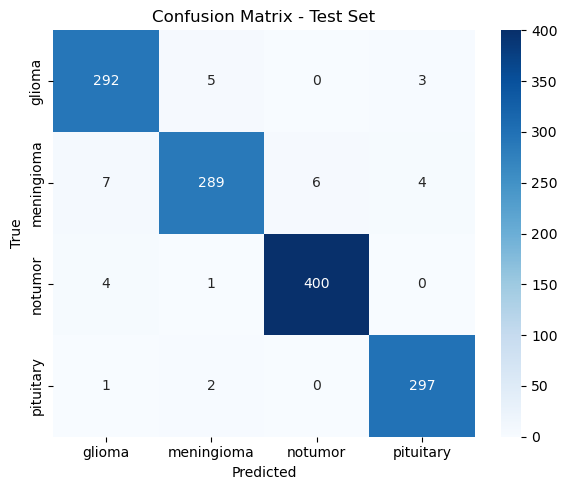

Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.97      0.97       300
  meningioma       0.97      0.94      0.96       306
     notumor       0.99      0.99      0.99       405
   pituitary       0.98      0.99      0.98       300

    accuracy                           0.97      1311
   macro avg       0.97      0.97      0.97      1311
weighted avg       0.97      0.97      0.97      1311

Test Accuracy: 0.9748283752860412


In [13]:
test_augmenter = ImageDataGenerator(preprocessing_function=preprocess_input)
test_loader = test_augmenter.flow_from_directory(
    test_directory,
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False)

test_loader.reset()
predicted_probs = model.predict(test_loader)
predicted_labels = numpy.argmax(predicted_probs, axis=1)
true_labels = test_loader.classes

cm = confusion_matrix(true_labels, predicted_labels)
plot.figure(figsize=(6, 5))
seaborn.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names)
plot.xlabel('Predicted')
plot.ylabel('True')
plot.title('Confusion Matrix - Test Set')
plot.tight_layout()
plot.show()

print('Classification Report:')
print(classification_report(true_labels, predicted_labels, target_names=class_names))
print('Test Accuracy:', accuracy_score(true_labels, predicted_labels))